<a href="https://colab.research.google.com/github/JonathanRosasV/Analisis-Discriminante/blob/main/ML4CCSS_CIES_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Recordar: Regresión polinómica

En la regresión polinómica en 1D, ajustamos un modelo

$$ f_\theta(x) := \theta^\top \phi(x) = \sum_{j=0}^p \theta_j x^j $$

que es lineal en $\theta$ pero no lineal en $x$ porque las características

$$\phi(x) = [1\; x\; \ldots\; x^p]$$

son no lineales. Usando estas características, podemos ajustar cualquier polinomio de grado $p$.

## Los polinomios ajustan bien los datos

Cuando pasamos de modelos lineales a polinomios, podemos ajustar mejor los datos y aumentar la precisión de nuestros modelos.
Generemos un conjunto de datos sintético para esta demostración.

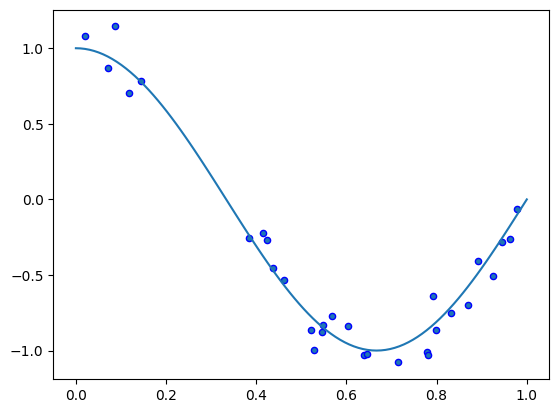

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

def true_fn(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_fn(X) + np.random.randn(n_samples) * 0.1

X_test = np.linspace(0, 1, 100)
plt.plot(X_test, true_fn(X_test), label="Verdadera Función")
plt.scatter(X, y, edgecolor='b', s=20, label="Muestras")
plt.show()

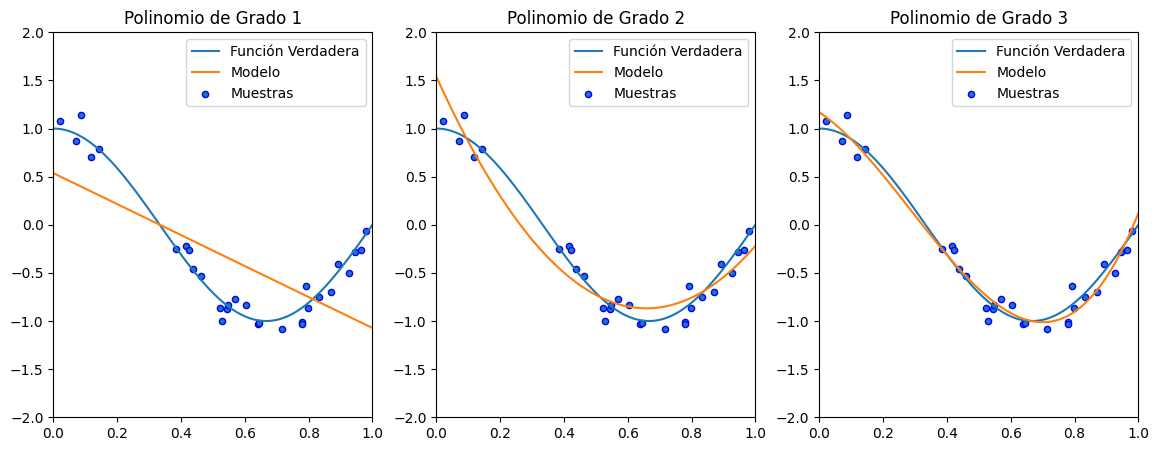

In [ ]:
degrees = [1, 2, 3]
plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    ax.plot(X_test, true_fn(X_test), label="Función Verdadera")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Modelo")
    ax.scatter(X, y, edgecolor='b', s=20, label="Muestras")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("Polinomio de Grado {}".format(degrees[i]))
plt.show()

# ¿A Mayor Grado Mejor?

A medida que aumentamos la complejidad de nuestra clase de modelos $\mathcal{M}$ para incluir polinomios de grado aún mayor, podemos ajustar los datos aún mejor.
¿Qué sucede si aumentamos aún más el grado del polinomio?

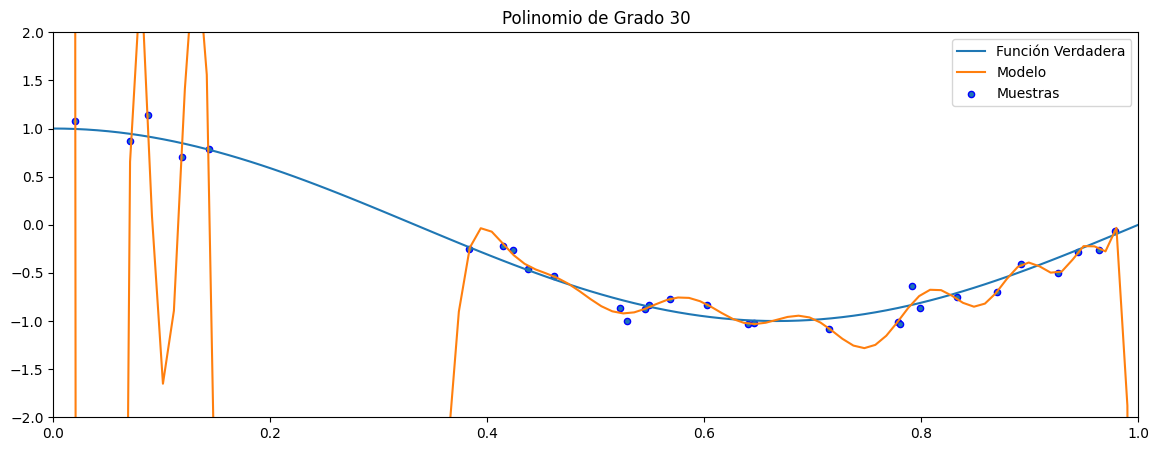

In [ ]:
degrees = [30]
plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    X_test = np.linspace(0, 1, 100)
    ax.plot(X_test, true_fn(X_test), label="Función Verdadera")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Modelo")
    ax.scatter(X, y, edgecolor='b', s=20, label="Muestras")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("Polinomio de Grado {}".format(degrees[i]))

In [ ]:
((pipeline.predict(X[:, np.newaxis]) - y) ** 2).mean() # error cuadrático medio en a muestra de entrenamiento

0.0021395112490140214

In [ ]:
X_validation = np.sort(np.random.rand(n_samples))
y_validation = true_fn(X_validation) + np.random.randn(n_samples) * 0.1
((pipeline.predict(X_validation[:, np.newaxis]) - y_validation) ** 2).mean() # error cuadrático medio en a muestra de validación

1154.3055196349537

## Sobreajuste vs. Subajuste: Evaluación

Podemos diagnosticar el sobreajuste y el subajuste midiendo el rendimiento en un conjunto de datos separado (no utilizado para el entrenamiento).

- Si el rendimiento en entrenamiento es __alto__ pero el rendimiento en el conjunto de validación es __bajo__, estamos sobreajustando.
- Si el rendimiento en entrenamiento es __bajo__ y el rendimiento en el conjunto de validación es __bajo__, estamos subajustando.

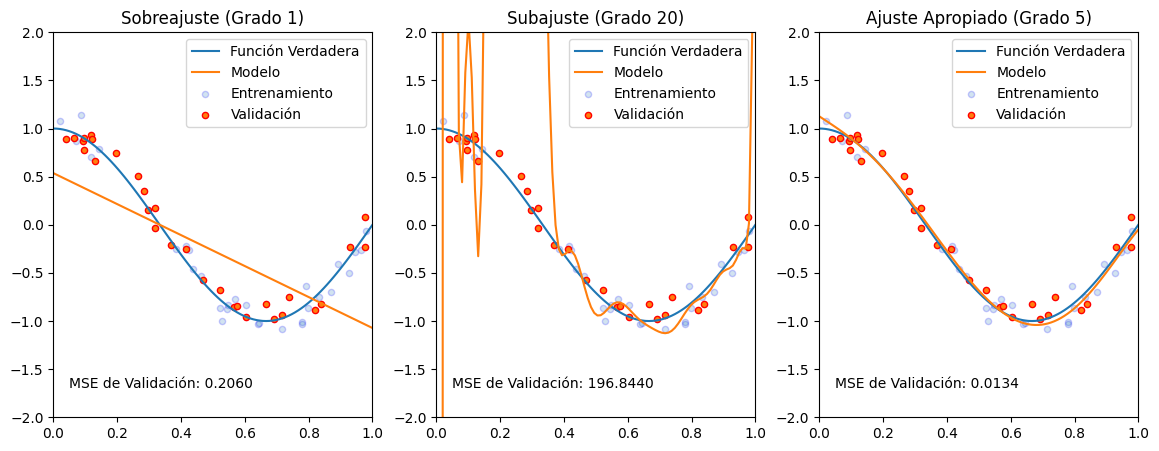

In [ ]:
degrees = [1, 20, 5]
titles = ['Sobreajuste', 'Subajuste', 'Ajuste Apropiado']
plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    ax.plot(X_test, true_fn(X_test), label="Función Verdadera")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Modelo")
    ax.scatter(X, y, edgecolor='b', s=20, label="Entrenamiento", alpha=0.2)
    ax.scatter(X_validation, y_validation, edgecolor='r', s=20, label="Validación")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("{} (Grado {})".format(titles[i], degrees[i]))
    ax.text(0.05,-1.7, 'MSE de Validación: %.4f' % ((y_validation-pipeline.predict(X_validation[:, np.newaxis]))**2).mean())

# Regularización: Intuición  

La idea de la regularización es penalizar modelos complejos que puedan sobreajustar los datos.  
En el ejemplo anterior, un modelo menos complejo dependería menos de términos polinómicos de grado alto.  

# Regularización: Definición  

La idea de la regularización es entrenar modelos con un objetivo aumentado $J : \mathcal{M} \to \mathbb{R}$ definido sobre un conjunto de datos de entrenamiento $\mathcal{D}$ de tamaño $n$ como  

$$J(f) = \underbrace{\frac{1}{n} \sum_{i=1}^n L(y^{(i)}, f(x^{(i)}))}_\text{Objetivo de Aprendizaje} + \underbrace{\lambda \cdot R(f)}_\text{Nuevo Término de Regularización}$$  

* El regularizador $R : \mathcal{M} \to \mathbb{R}$ penaliza los modelos complejos.  
* El hiperparámetro $\lambda > 0$ controla la intensidad del regularizador.  

Desglosemos los componentes de este objetivo:  

* Una función de pérdida $L(y, f(x))$ como el error cuadrático medio.  
* Un regularizador $R : \mathcal{M} \to \mathbb{R}$ que penaliza los modelos excesivamente complejos.  
* Un parámetro de regularización $\lambda > 0$, que controla la fuerza del regularizador.  

Cuando el modelo $f_\theta$ está parametrizado por parámetros $\theta$, también usamos la siguiente notación:  

$$J(\theta) = \frac{1}{n} \sum_{i=1}^n L(y^{(i)}, f_\theta(x^{(i)})) + \lambda \cdot R(\theta).$$  

# Regularización $\ell_2$: Definición  

¿Cómo podemos definir un regularizador $R: \mathcal{M} \to \mathbb{R}$ para controlar la complejidad de un modelo $f \in \mathcal{M}$?  
En el contexto de modelos lineales $f_\theta(x) = \theta^\top x$, un enfoque ampliamente utilizado es la regularización $\ell_2$, que define el siguiente objetivo:  

$$J(\theta) = \frac{1}{n} \sum_{i=1}^n L(y^{(i)}, \theta^\top x^{(i)}) + \lambda \cdot ||\theta||_2^2.$$  

Desglosemos los componentes de este objetivo:  

* El regularizador $R : \mathcal{M} \to \mathbb{R}$ es la función  
  $R(\theta) = ||\theta||_2^2 = \sum_{j=1}^d \theta_j^2.$  
  Esto también se conoce como la norma $\ell_2$ de $\theta$.  
* El regularizador penaliza parámetros grandes, evitando que dependamos demasiado de una sola característica y penalizando soluciones muy irregulares.  
* La regularización $\ell_2$ se puede usar con la mayoría de los modelos (lineales, neuronales, etc.).  

# Regularización $\ell_2$ para la regresión polinómica  

Consideremos una aplicación al modelo polinómico que hemos visto hasta ahora. Dadas las características polinómicas $\phi(x)$, optimizamos el siguiente objetivo:  

$$ J(\theta) = \frac{1}{2n} \sum_{i=1}^n \left( y^{(i)} - \theta^\top \phi(x^{(i)}) \right)^2 + \lambda \cdot ||\theta||_2^2. $$  

Implementamos regresión polinómica regularizada de grado 15 en tres conjuntos de entrenamiento aleatorios extraídos de la misma distribución.  

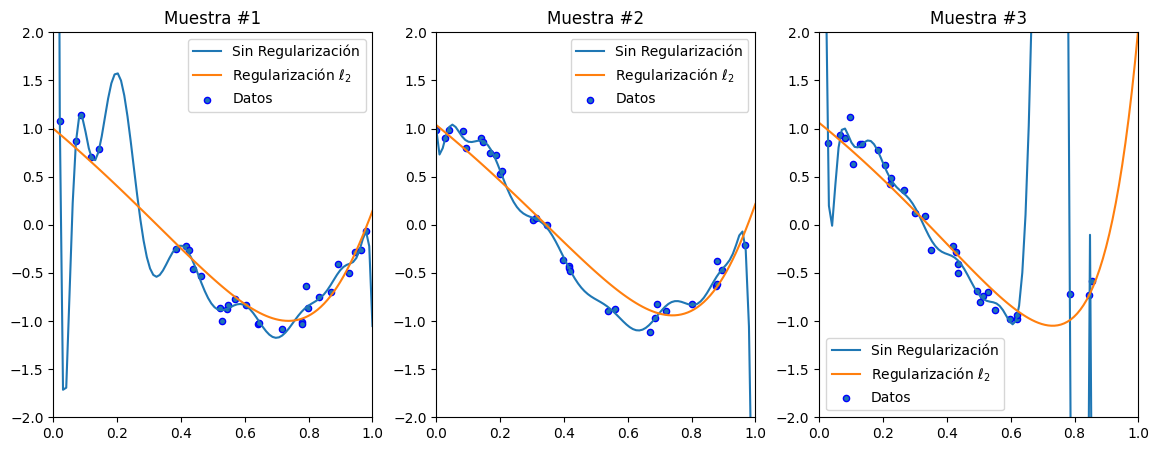

In [ ]:
from sklearn.linear_model import Ridge

degrees = [15, 15, 15]
plt.figure(figsize=(14, 5))
for idx, i in enumerate(range(len(degrees))):
    # sample a dataset
    np.random.seed(idx)
    n_samples = 30
    X = np.sort(np.random.rand(n_samples))
    y = true_fn(X) + np.random.randn(n_samples) * 0.1

    # fit a least squares model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # fit a Ridge model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = Ridge(alpha=0.1) # sklearn uses alpha instead of lambda
    pipeline2 = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline2.fit(X[:, np.newaxis], y)

    # visualize results
    ax = plt.subplot(1, len(degrees), i + 1)
    # ax.plot(X_test, true_fn(X_test), label="True function")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Sin Regularización")
    ax.plot(X_test, pipeline2.predict(X_test[:, np.newaxis]), label="Regularización $\ell_2$")
    ax.scatter(X, y, edgecolor='b', s=20, label="Datos")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("Muestra #{}".format(idx + 1))


# Regularización $\ell_1$: Definición  

Otro enfoque es penalizar el tamaño de los pesos utilizando la norma $\ell_1$.  

En el contexto de modelos lineales $f(x) = \theta^\top x$, la regularización $\ell_1$ produce el siguiente objetivo:  

$$ J(\theta) = \frac{1}{n} \sum_{i=1}^n L(y^{(i)}, \theta^\top x^{(i)}) + \lambda \cdot ||\theta||_1. $$  

Desglosemos los componentes de este objetivo:  

* El regularizador $R : \mathcal{M} \to \mathbb{R}$ es  
  $R(\theta) = ||\theta||_1 = \sum_{j=1}^d |\theta_j|.$  
  Esto se conoce como la norma $\ell_1$ de $\theta$.  
* Este regularizador también penaliza pesos grandes. Además, fuerza a que la mayoría de los pesos decaigan hasta cero, en lugar de solo ser pequeños.

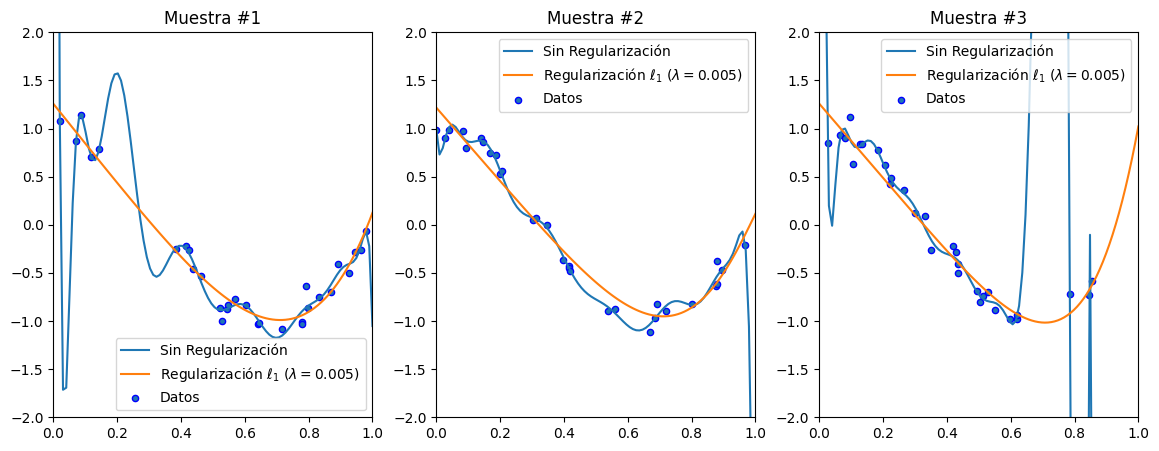

In [ ]:
from sklearn.linear_model import Lasso

degrees = [15, 15, 15]
plt.figure(figsize=(14, 5))
for idx, i in enumerate(range(len(degrees))):
    # sample a dataset
    np.random.seed(idx)
    n_samples = 30
    X = np.sort(np.random.rand(n_samples))
    y = true_fn(X) + np.random.randn(n_samples) * 0.1

    # fit a least squares model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # fit a Lasso model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = Lasso(alpha=0.001, max_iter = 1500) # sklearn uses alpha instead of lambda
    pipeline2 = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline2.fit(X[:, np.newaxis], y)

    # visualize results
    ax = plt.subplot(1, len(degrees), i + 1)
    # ax.plot(X_test, true_fn(X_test), label="True function")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Sin Regularización")
    ax.plot(X_test, pipeline2.predict(X_test[:, np.newaxis]), label="Regularización $\ell_1$ ($\lambda = 0.005$)")
    ax.scatter(X, y, edgecolor='b', s=20, label="Datos")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("Muestra #{}".format(idx + 1))


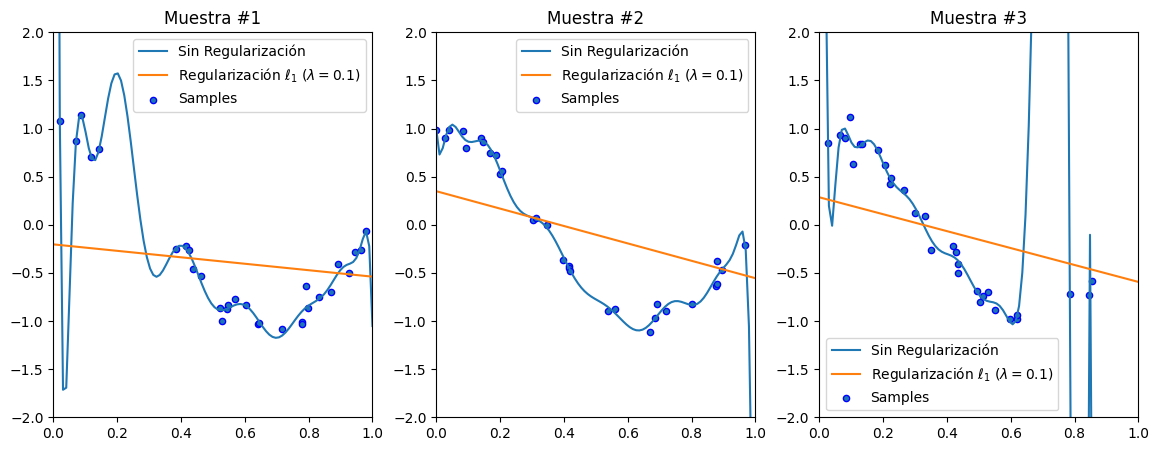

In [ ]:
degrees = [15, 15, 15]
plt.figure(figsize=(14, 5))
for idx, i in enumerate(range(len(degrees))):
    # sample a dataset
    np.random.seed(idx)
    n_samples = 30
    X = np.sort(np.random.rand(n_samples))
    y = true_fn(X) + np.random.randn(n_samples) * 0.1

    # fit a least squares model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # fit a Lasso model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = Lasso(alpha=0.1) # sklearn uses alpha instead of lambda
    pipeline2 = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline2.fit(X[:, np.newaxis], y)

    # visualize results
    ax = plt.subplot(1, len(degrees), i + 1)
    # ax.plot(X_test, true_fn(X_test), label="True function")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Sin Regularización")
    ax.plot(X_test, pipeline2.predict(X_test[:, np.newaxis]), label="Regularización $\ell_1$ ($\lambda = 0.1$)")
    ax.scatter(X, y, edgecolor='b', s=20, label="Samples")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("Muestra #{}".format(idx + 1))

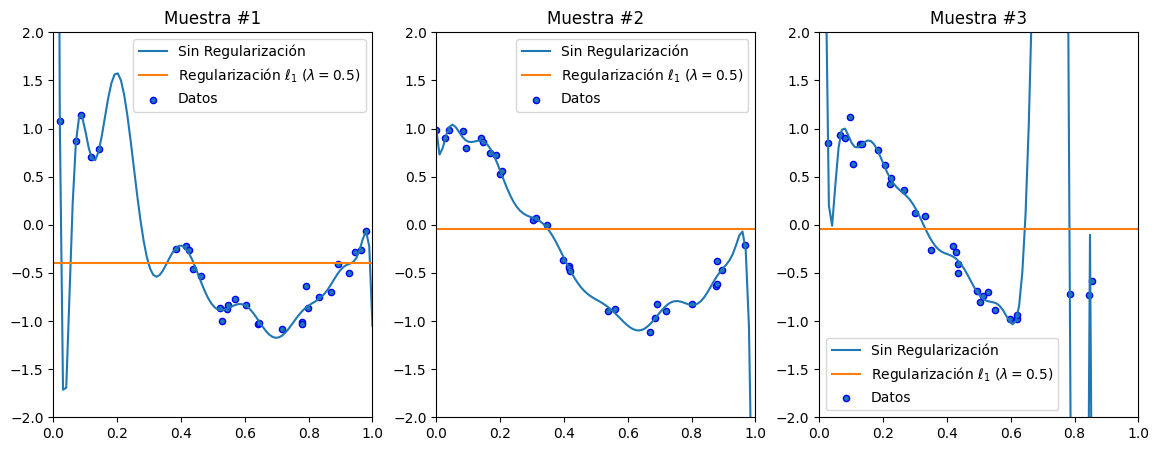

In [ ]:
degrees = [15, 15, 15]
plt.figure(figsize=(14, 5))
for idx, i in enumerate(range(len(degrees))):
    # sample a dataset
    np.random.seed(idx)
    n_samples = 30
    X = np.sort(np.random.rand(n_samples))
    y = true_fn(X) + np.random.randn(n_samples) * 0.1

    # fit a least squares model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # fit a Lasso model
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = Lasso(alpha=0.5) # sklearn uses alpha instead of lambda
    pipeline2 = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline2.fit(X[:, np.newaxis], y)

    # visualize results
    ax = plt.subplot(1, len(degrees), i + 1)
    # ax.plot(X_test, true_fn(X_test), label="True function")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Sin Regularización")
    ax.plot(X_test, pipeline2.predict(X_test[:, np.newaxis]), label="Regularización $\ell_1$ ($\lambda = 0.5$)")
    ax.scatter(X, y, edgecolor='b', s=20, label="Datos")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title("Muestra #{}".format(idx + 1))

# Dispersión: Definición  

Se dice que un vector es disperso si una gran fracción de sus valores es igual a cero.  
La regresión lineal regularizada con $\ell_1$ produce *parámetros dispersos* $\theta$.  
* Esto hace que el modelo sea más interpretable.  
* También lo hace computacionalmente más manejable en dimensiones muy grandes.
* Sin embargo, esta propiedad provoca la expulsión de variables multicolineales con otras, lo cual puede provocar un peor rendimiento predictivo.

# Dispersión: Ridge vs. Lasso  

Para comprender mejor la dispersión, ajustamos Ridge y Lasso en el conjunto de datos de diabetes de UCI y observamos la magnitud de cada peso (líneas coloreadas) como función del parámetro de regularización.

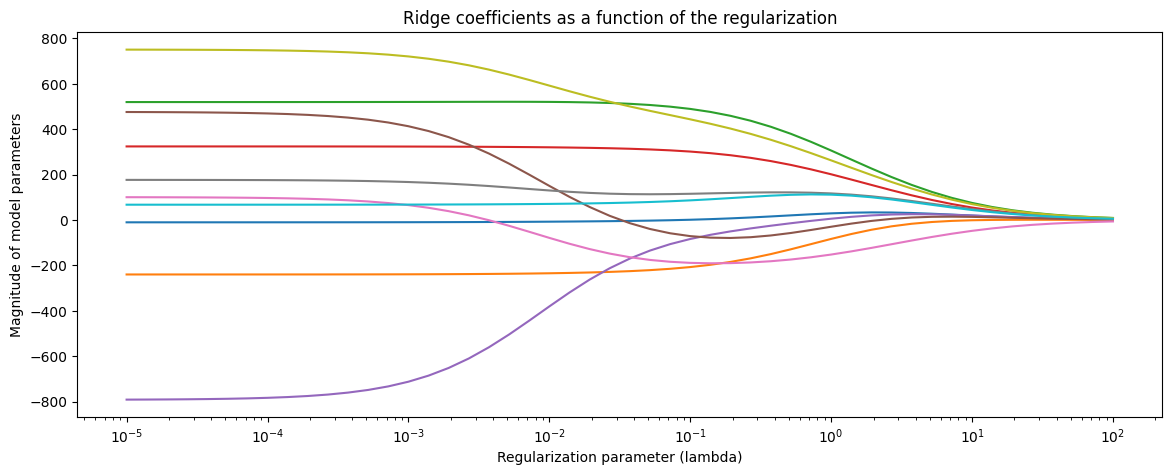

In [ ]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)

# create ridge coefficients
alphas = np.logspace(-5, 2,  )
ridge_coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X, y)
    ridge_coefs.append(ridge.coef_)

# plot ridge coefficients
plt.figure(figsize=(14, 5))
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.xlabel('Regularization parameter (lambda)')
plt.ylabel('Magnitude of model parameters')
plt.title('Ridge coefficients as a function of the regularization')
plt.axis('tight')
plt.show()

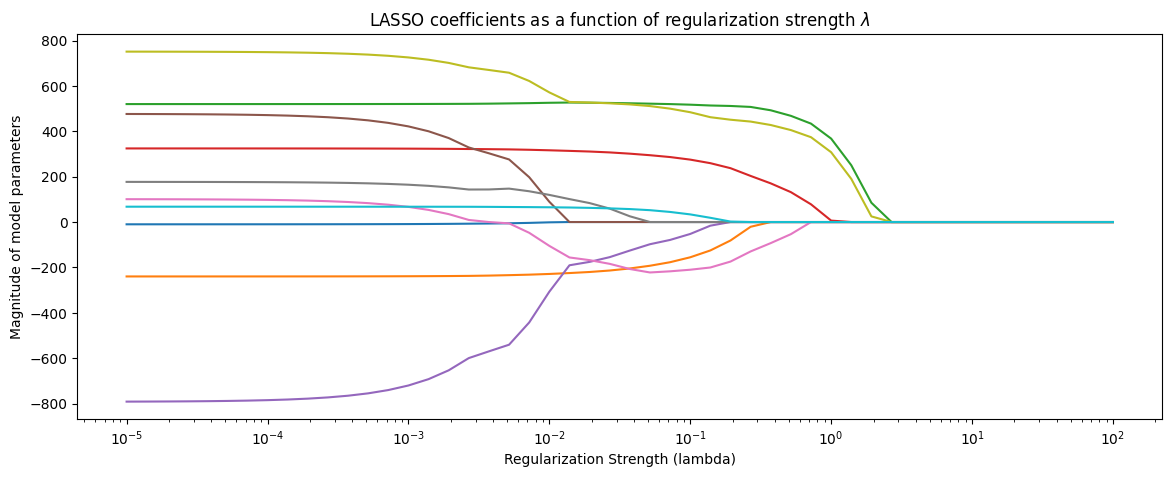

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# create lasso coefficients
alphas = np.logspace(-5, 2,  )
lasso_coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, fit_intercept=False)
    lasso.fit(X, y)
    lasso_coefs.append(lasso.coef_)

plt.figure(figsize=(14, 5))
plt.plot(alphas, lasso_coefs)
ymin, ymax = plt.ylim()
plt.xscale('log')
plt.ylabel('Magnitude of model parameters')
plt.xlabel('Regularization Strength (lambda)')
plt.title('LASSO coefficients as a function of regularization strength $\lambda$')
plt.axis('tight')
plt.show()

Los parámetros de Lasso se vuelven progresivamente más pequeños, hasta que alcanzan exactamente cero y permanecen en cero. Por otro lado, los parámetros de Ridge también se vuelven más pequeños de forma progresiva, pero no alcanzan exactamente cero.